# The Anglo-Saxon Exception: Inequality Across Developed Economies

## Introduction

This blog post examines trends in income inequality across developed economies 
since the 1980s, with a particular focus on whether English-speaking nations 
have followed a different path to their continental European counterparts.

We use data from the World Inequality Database (WID) and the OECD to compare 
Gini coefficients and income shares across a selection of countries including 
the US, UK, Germany, France, Sweden, and Canada.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import requests
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


## Data Collection

We collect Gini coefficient data from the OECD Income Distribution Database, 
covering a selection of developed economies from 1980 to present.

In [2]:
import pandas as pd
import requests

# Define our country selection
countries = ['USA', 'GBR', 'DEU', 'FRA', 'SWE', 'CAN', 'AUS', 'NOR', 'DNK']

# Pull Gini coefficient data from OECD API
url = "https://stats.oecd.org/SDMX-JSON/data/IDD/{}..GINI.../all?startTime=1980&endTime=2023".format("+".join(countries))

response = requests.get(url)
print("Status code:", response.status_code)
print("Response received")

Status code: 404
Response received


In [3]:
import pandas as pd

# Load the raw data
df = pd.read_csv('data/raw/oecd_gini.csv')

# First look at the data
print(df.shape)
print(df.head())
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/oecd_gini.csv'

In [4]:
import pandas as pd

# Load the raw data
df = pd.read_csv('../data/raw/oecd_gini.csv')

# First look at the data
print(df.shape)
print(df.head())
print(df.columns.tolist())

(289, 40)
  STRUCTURE                            STRUCTURE_ID  \
0  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
1  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
2  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
3  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   
4  DATAFLOW  OECD.WISE.INE:DSD_WISE_IDD@DF_IDD(1.0)   

                 STRUCTURE_NAME ACTION REF_AREA Reference area FREQ  \
0  Income distribution database      I      SWE         Sweden    A   
1  Income distribution database      I      SWE         Sweden    A   
2  Income distribution database      I      SWE         Sweden    A   
3  Income distribution database      I      SWE         Sweden    A   
4  Income distribution database      I      NOR         Norway    A   

  Frequency of observation        MEASURE                   Measure  ...  \
0                   Annual  INC_DISP_GINI  Gini (disposable income)  ...   
1                   Annual  INC_DISP_GINI  Gini (disposable income)  ...   
2   

In [5]:
# Keep only the columns we need
df_clean = df[['REF_AREA', 'Reference area', 'TIME_PERIOD', 'OBS_VALUE']].copy()

# Rename columns to something cleaner
df_clean.columns = ['country_code', 'country', 'year', 'gini']

# Convert year and gini to numeric
df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')
df_clean['gini'] = pd.to_numeric(df_clean['gini'], errors='coerce')

# Drop any missing values
df_clean = df_clean.dropna()

# Check the result
print(df_clean.shape)
print(df_clean.head(10))
print(df_clean['country'].unique())
print(df_clean['year'].min(), "-", df_clean['year'].max())


(289, 4)
  country_code  country  year      gini
0          SWE   Sweden  2000  0.243000
1          SWE   Sweden  1995  0.211000
2          SWE   Sweden  1991  0.209000
3          SWE   Sweden  1983  0.198000
4          NOR   Norway  2011  0.250000
5          DNK  Denmark  2011  0.250500
6          CAN   Canada  2023  0.306000
7          CAN   Canada  1995  0.293375
8          CAN   Canada  1994  0.291138
9          CAN   Canada  1993  0.290296
<StringArray>
[        'Sweden',         'Norway',        'Denmark',         'Canada',
  'United States',        'Germany',         'France',      'Australia',
 'United Kingdom']
Length: 9, dtype: str
1980 - 2023


In [6]:
# Save cleaned data to processed folder
df_clean.to_csv('../data/processed/gini_clean.csv', index=False)
print("Cleaned data saved successfully")

Cleaned data saved successfully


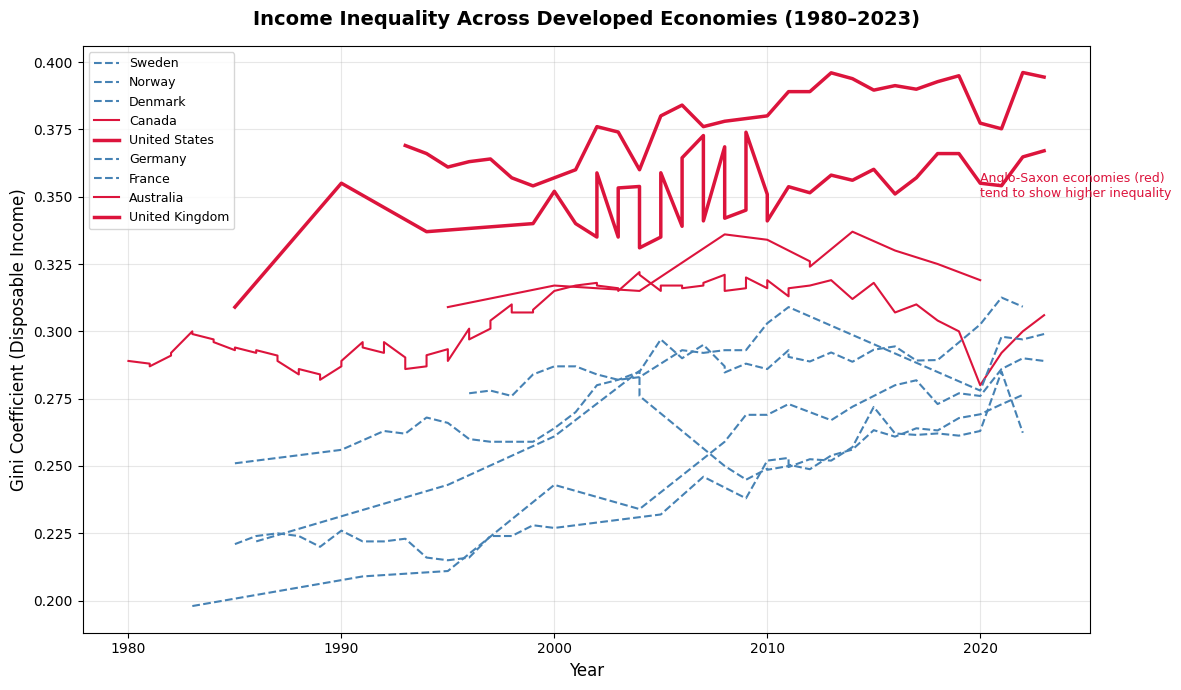

Chart saved!


In [7]:
import matplotlib.pyplot as plt

# Define country groups for colouring
anglo_saxon = ['United States', 'United Kingdom', 'Canada', 'Australia']
continental = ['Germany', 'France', 'Sweden', 'Norway', 'Denmark']

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

for country in df_clean['country'].unique():
    data = df_clean[df_clean['country'] == country].sort_values('year')
    color = 'crimson' if country in anglo_saxon else 'steelblue'
    linewidth = 2.5 if country in ['United States', 'United Kingdom'] else 1.5
    linestyle = '-' if country in anglo_saxon else '--'
    ax.plot(data['year'], data['gini'], 
            label=country, color=color, 
            linewidth=linewidth, linestyle=linestyle)

ax.set_title('Income Inequality Across Developed Economies (1980–2023)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Gini Coefficient (Disposable Income)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Add annotation
ax.annotate('Anglo-Saxon economies (red)\ntend to show higher inequality', 
            xy=(2020, 0.35), fontsize=9, color='crimson')

plt.tight_layout()
plt.savefig('../output/figures/gini_trends.png', dpi=150)
plt.show()
print("Chart saved!")

In [8]:
# Check US data specifically
us_data = df_clean[df_clean['country'] == 'United States'].sort_values('year')
print(us_data)

    country_code        country  year      gini
268          USA  United States  1993  0.369000
267          USA  United States  1994  0.366000
266          USA  United States  1995  0.361000
265          USA  United States  1996  0.363000
264          USA  United States  1997  0.364000
263          USA  United States  1998  0.357000
262          USA  United States  1999  0.354000
261          USA  United States  2000  0.357000
260          USA  United States  2001  0.360000
259          USA  United States  2002  0.376000
258          USA  United States  2003  0.374000
257          USA  United States  2004  0.360000
256          USA  United States  2005  0.380000
255          USA  United States  2006  0.384000
254          USA  United States  2007  0.376000
253          USA  United States  2008  0.378000
252          USA  United States  2009  0.379000
251          USA  United States  2010  0.380000
250          USA  United States  2011  0.389000
249          USA  United States  2012  0

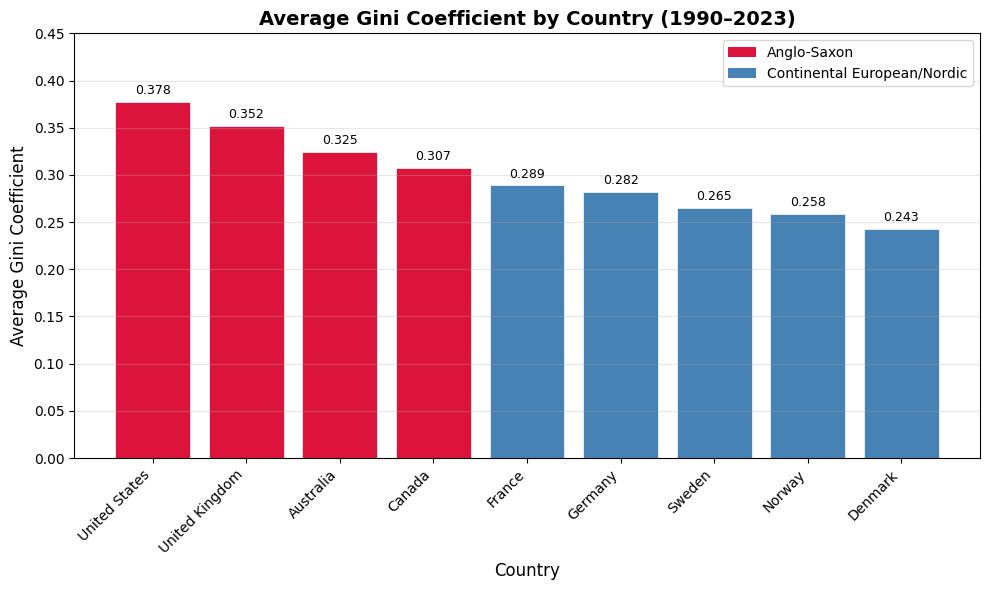

Chart saved!


In [9]:
# Average Gini by country (post-1990 for fair comparison)
avg_gini = df_clean[df_clean['year'] >= 1990].groupby('country')['gini'].mean().sort_values(ascending=False)

# Define colours
colors = ['crimson' if c in anglo_saxon else 'steelblue' for c in avg_gini.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_gini.index, avg_gini.values, color=colors, edgecolor='white', linewidth=0.5)

ax.set_title('Average Gini Coefficient by Country (1990–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Average Gini Coefficient', fontsize=12)
ax.set_ylim(0, 0.45)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, avg_gini.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='crimson', label='Anglo-Saxon'),
                   Patch(facecolor='steelblue', label='Continental European/Nordic')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../output/figures/gini_average.png', dpi=150)
plt.show()
print("Chart saved!")

ValueError: 'x' has size 44, but 'y2' has an unequal size of 40

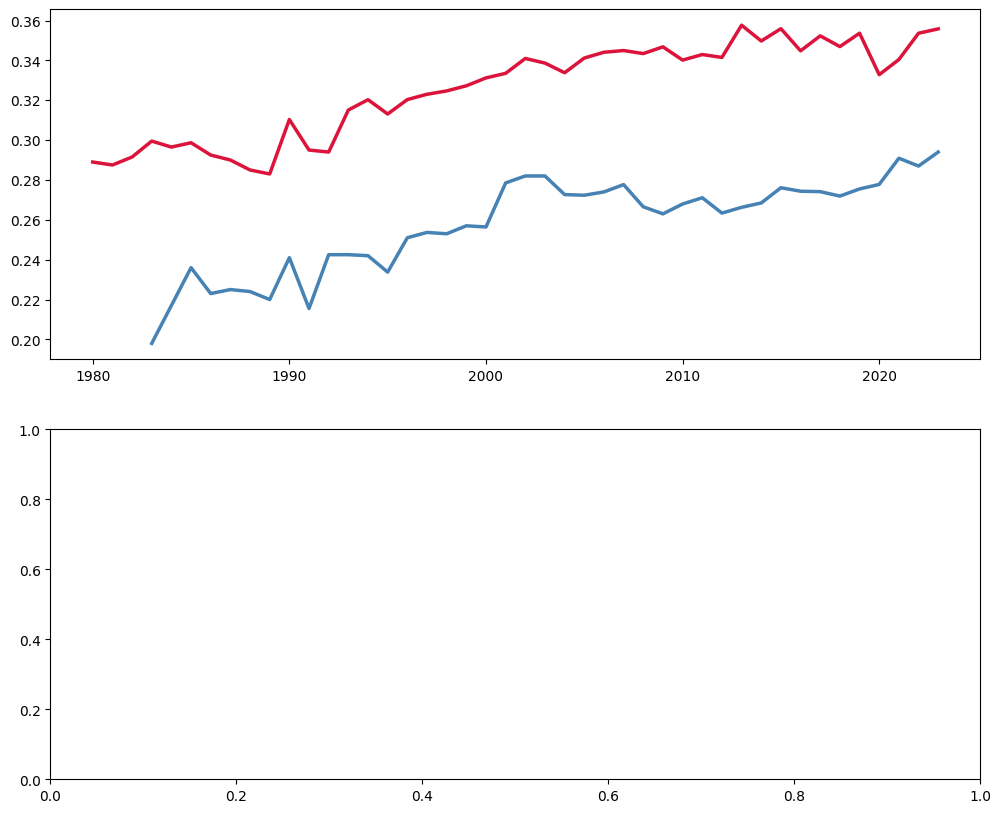

In [10]:
# Calculate average Gini for each group per year
df_clean['group'] = df_clean['country'].apply(
    lambda x: 'Anglo-Saxon' if x in anglo_saxon else 'Continental/Nordic'
)

group_avg = df_clean.groupby(['year', 'group'])['gini'].mean().reset_index()

anglo_data = group_avg[group_avg['group'] == 'Anglo-Saxon'].sort_values('year')
continental_data = group_avg[group_avg['group'] == 'Continental/Nordic'].sort_values('year')

# Merge to calculate gap
merged = anglo_data.merge(continental_data, on='year', suffixes=('_anglo', '_continental'))
merged['gap'] = merged['gini_anglo'] - merged['gini_continental']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top chart - group averages over time
ax1.plot(anglo_data['year'], anglo_data['gini'], 
         color='crimson', linewidth=2.5, label='Anglo-Saxon average')
ax1.plot(continental_data['year'], continental_data['gini'], 
         color='steelblue', linewidth=2.5, label='Continental/Nordic average')
ax1.fill_between(anglo_data['year'], anglo_data['gini'], continental_data['gini'],
                 alpha=0.15, color='crimson')
ax1.set_title('Group Average Gini Coefficients Over Time', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Gini Coefficient', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom chart - the gap over time
ax2.plot(merged['year'], merged['gap'], color='purple', linewidth=2.5)
ax2.axhline(y=merged['gap'].mean(), color='gray', linestyle='--', alpha=0.7, label='Average gap')
ax2.fill_between(merged['year'], merged['gap'], alpha=0.15, color='purple')
ax2.set_title('Inequality Gap: Anglo-Saxon minus Continental/Nordic', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Gini Gap', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/gini_gap.png', dpi=150)
plt.show()
print("Chart saved!")

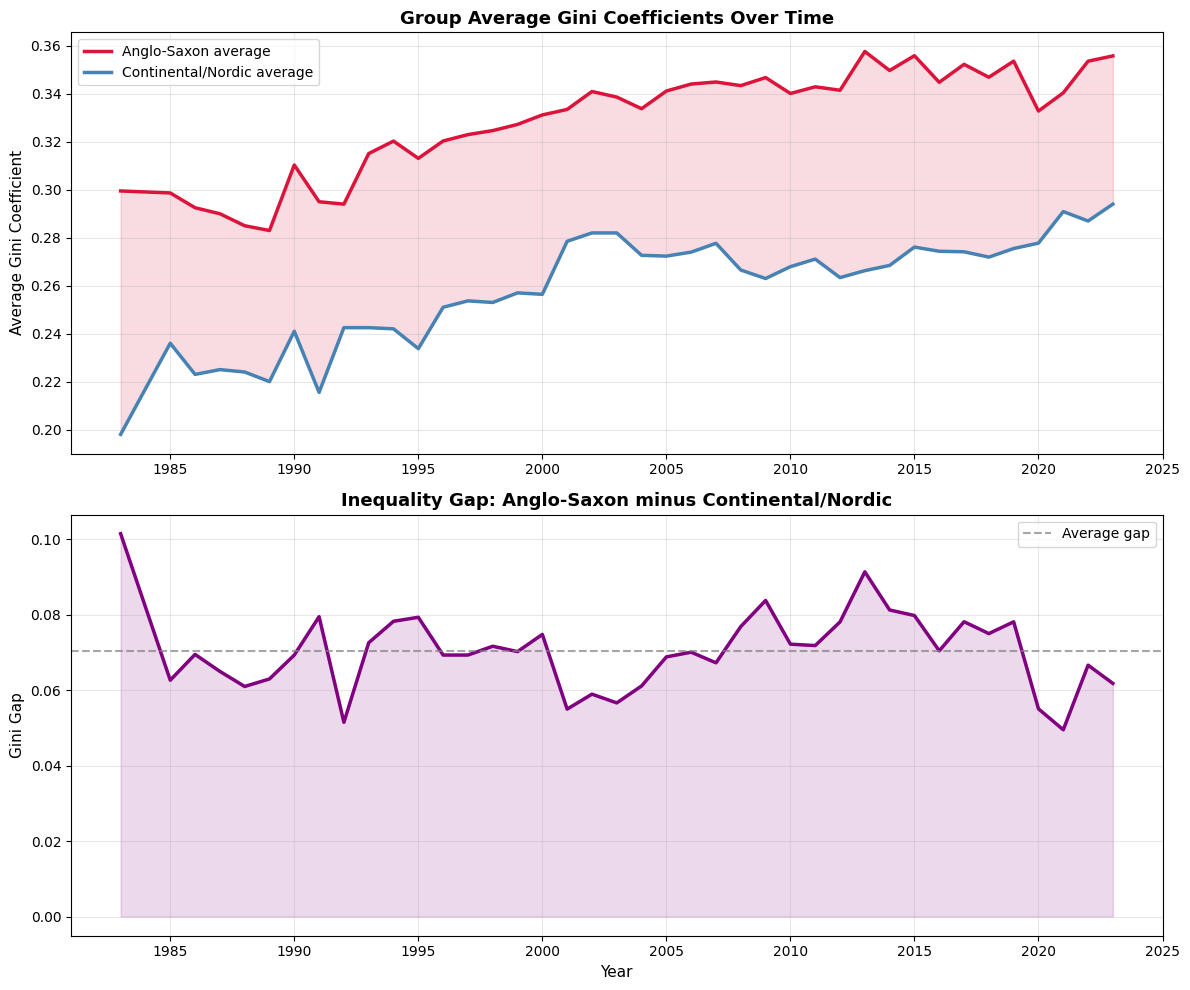

Chart saved!


In [11]:
# Calculate average Gini for each group per year
df_clean['group'] = df_clean['country'].apply(
    lambda x: 'Anglo-Saxon' if x in anglo_saxon else 'Continental/Nordic'
)

group_avg = df_clean.groupby(['year', 'group'])['gini'].mean().reset_index()

anglo_data = group_avg[group_avg['group'] == 'Anglo-Saxon'].sort_values('year')
continental_data = group_avg[group_avg['group'] == 'Continental/Nordic'].sort_values('year')

# Merge to get only years where both groups have data
merged = anglo_data.merge(continental_data, on='year', suffixes=('_anglo', '_continental'))
merged['gap'] = merged['gini_anglo'] - merged['gini_continental']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top chart - use merged data so both series have same years
ax1.plot(merged['year'], merged['gini_anglo'], 
         color='crimson', linewidth=2.5, label='Anglo-Saxon average')
ax1.plot(merged['year'], merged['gini_continental'], 
         color='steelblue', linewidth=2.5, label='Continental/Nordic average')
ax1.fill_between(merged['year'], merged['gini_anglo'], merged['gini_continental'],
                 alpha=0.15, color='crimson')
ax1.set_title('Group Average Gini Coefficients Over Time', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Gini Coefficient', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom chart - the gap over time
ax2.plot(merged['year'], merged['gap'], color='purple', linewidth=2.5)
ax2.axhline(y=merged['gap'].mean(), color='gray', linestyle='--', alpha=0.7, label='Average gap')
ax2.fill_between(merged['year'], merged['gap'], alpha=0.15, color='purple')
ax2.set_title('Inequality Gap: Anglo-Saxon minus Continental/Nordic', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Gini Gap', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/figures/gini_gap.png', dpi=150)
plt.show()
print("Chart saved!")